Libraries

In [21]:
!pip install -U kaleido

In [28]:
# ==========================================
# CELL 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("Libraries imported successfully.")

Libraries imported successfully.


Data Loading

In [29]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("File loaded successfully:", file_name)
print("Initial Dataset Shape:", df.shape)
df.head()

Saving Unemployment in India.csv to Unemployment in India (1).csv
File loaded successfully: Unemployment in India (1).csv
Initial Dataset Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Data Checking & Cleaning

In [30]:
df.columns = df.columns.str.strip()

df = df.dropna(how="all")
df = df.dropna(subset=["Date", "Estimated Unemployment Rate (%)"])

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

rename_dict = {
    "Region": "State",
    "Frequency": "Frequency",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
    "Area": "Area",
    "Region.1": "Zone",
}
df = df.rename(
    columns={k: v for k, v in rename_dict.items() if k in df.columns}
)

numeric_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("--- SANITIZATION SUMMARY ---")
print("Cleaned Dataset Shape:", df.shape)
print("Remaining Null Values:\n", df.isnull().sum())

--- SANITIZATION SUMMARY ---
Cleaned Dataset Shape: (740, 7)
Remaining Null Values:
 State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64


Feature Engineering

In [31]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

def categorize_phase(date):
    if date < pd.Timestamp("2020-04-01"):
        return "1. Pre-Lockdown (Jan - Mar 2020 / 2019)"
    elif pd.Timestamp("2020-04-01") <= date <= pd.Timestamp("2020-05-31"):
        return "2. Peak Lockdown Shock (Apr - May 2020)"
    else:
        return "3. Unlock & Phased Recovery (Jun 2020+)"

df["Lockdown_Phase"] = df["Date"].apply(categorize_phase)

df["Unemp_to_LFPR_Ratio"] = (
    df["Unemployment_Rate"] / df["Labour_Participation_Rate"]
).round(4)

if df["Employed"].max() > 1e5:
    df["Employed_Millions"] = (df["Employed"] / 1e6).round(2)
else:
    df["Employed_Millions"] = df["Employed"]

print("Feature engineering complete. Preview of transformed data:")
display(df[["Date", "Lockdown_Phase", "Unemployment_Rate", "Labour_Participation_Rate", "Unemp_to_LFPR_Ratio", "Employed_Millions"]].head())

Feature engineering complete. Preview of transformed data:


,Date,Lockdown_Phase,Unemployment_Rate,Labour_Participation_Rate,Unemp_to_LFPR_Ratio,Employed_Millions
0,2019-05-31,1. Pre-Lockdown (Jan - Mar 2020 / 2019),3.65,43.24,0.0844,12.00
1,2019-06-30,1. Pre-Lockdown (Jan - Mar 2020 / 2019),3.05,42.05,0.0725,11.76
2,2019-07-31,1. Pre-Lockdown (Jan - Mar 2020 / 2019),3.75,43.50,0.0862,12.09
3,2019-08-31,1. Pre-Lockdown (Jan - Mar 2020 / 2019),3.32,43.97,0.0755,12.29
4,2019-09-30,1. Pre-Lockdown (Jan - Mar 2020 / 2019),5.17,44.68,0.1157,12.26


Summary Statistics

In [32]:
print("--- MACRO INDICATORS BY LOCKDOWN PHASE ---")
phase_stats = (
    df.groupby("Lockdown_Phase")
    .agg(
        Avg_Unemployment=("Unemployment_Rate", "mean"),
        Median_Unemployment=("Unemployment_Rate", "median"),
        Max_Unemployment=("Unemployment_Rate", "max"),
        Avg_LFPR=("Labour_Participation_Rate", "mean"),
        Avg_Employed_Millions=("Employed_Millions", "mean"),
    )
    .round(2)
)
display(phase_stats)

if "Area" in df.columns:
    print("\n--- URBAN VS. RURAL UNEMPLOYMENT RATE (%) ---")
    area_pivot = df.pivot_table(
        index="Lockdown_Phase",
        columns="Area",
        values="Unemployment_Rate",
        aggfunc="mean",
    ).round(2)
    display(area_pivot)

--- MACRO INDICATORS BY LOCKDOWN PHASE ---


,Avg_Unemployment,Median_Unemployment,Max_Unemployment,Avg_LFPR,Avg_Employed_Millions
Lockdown_Phase,,,,,
1. Pre-Lockdown (Jan - Mar 2020 / 2019),9.61,7.22,34.69,43.82,7.47
2. Peak Lockdown Shock (Apr - May 2020),24.26,19.96,76.74,36.82,5.58
3. Unlock & Phased Recovery (Jun 2020+),11.90,10.34,35.57,40.55,7.39



--- URBAN VS. RURAL UNEMPLOYMENT RATE (%) ---


Area,Rural,Urban
Lockdown_Phase,,
1. Pre-Lockdown (Jan - Mar 2020 / 2019),8.23,10.91
2. Peak Lockdown Shock (Apr - May 2020),21.48,26.93
3. Unlock & Phased Recovery (Jun 2020+),11.83,11.98


Visualization

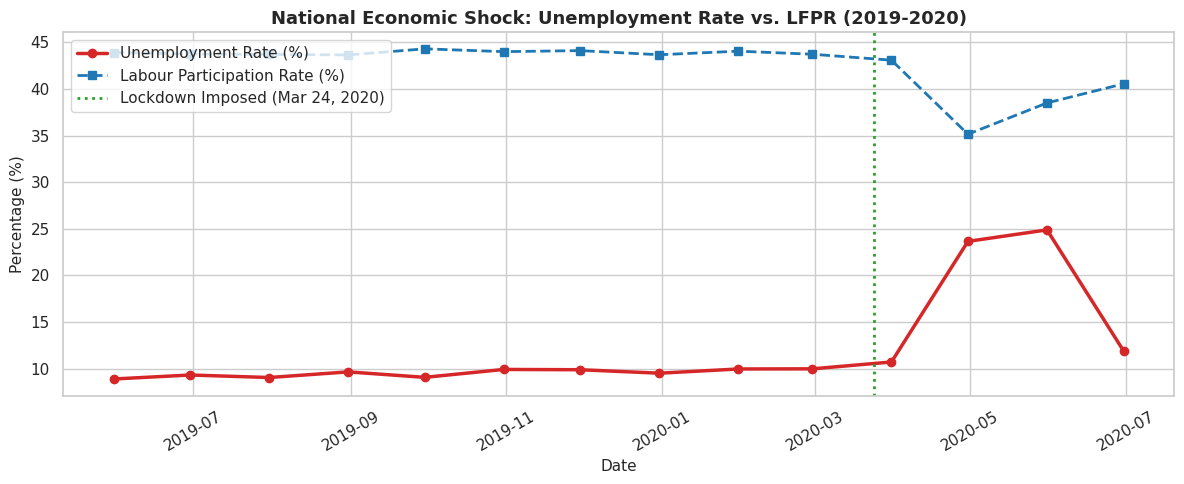

In [34]:
national_trend = (
    df.groupby("Date")
    .agg(
        Mean_Unemployment=("Unemployment_Rate", "mean"),
        Mean_LFPR=("Labour_Participation_Rate", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    national_trend["Date"],
    national_trend["Mean_Unemployment"],
    color="#d62728",
    linewidth=2.5,
    marker="o",
    label="Unemployment Rate (%)",
)
plt.plot(
    national_trend["Date"],
    national_trend["Mean_LFPR"],
    color="#1f77b4",
    linewidth=2,
    linestyle="--",
    marker="s",
    label="Labour Participation Rate (%)",
)

plt.axvline(
    pd.Timestamp("2020-03-24"),
    color="#2ca02c",
    linestyle=":",
    linewidth=2,
    label="Lockdown Imposed (Mar 24, 2020)",
)

plt.title(
    "National Economic Shock: Unemployment Rate vs. LFPR (2019-2020)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)
plt.legend(loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

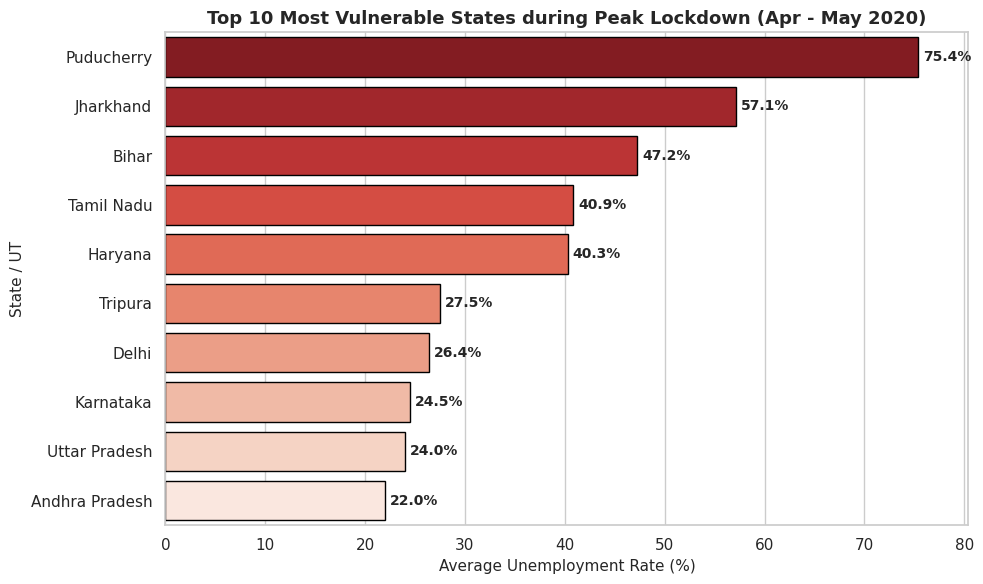

In [35]:
peak_mask = df["Lockdown_Phase"].str.contains("Peak Lockdown Shock")
top_states = (
    df[peak_mask]
    .groupby("State")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,
    palette="Reds_r",
    legend=False,
    edgecolor="black",
)

for i, v in enumerate(top_states.values):
  plt.text(v + 0.5, i, f"{v:.1f}%", va="center", weight="bold", fontsize=10)

plt.title(
    "Top 10 Most Vulnerable States during Peak Lockdown (Apr - May 2020)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Average Unemployment Rate (%)", fontsize=11)
plt.ylabel("State / UT", fontsize=11)
plt.xlim(0, max(top_states.values) + 5)
plt.tight_layout()
plt.show()

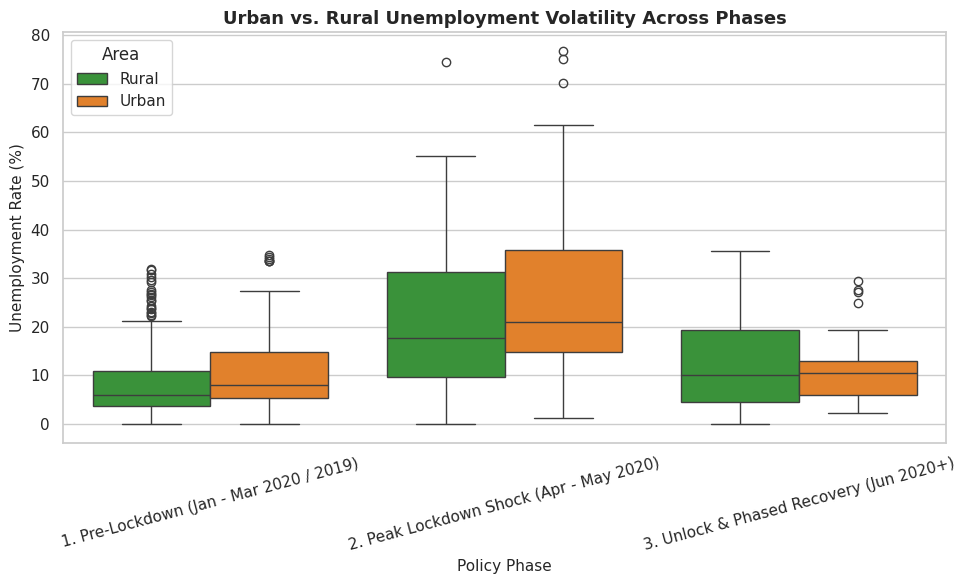

In [36]:
if "Area" in df.columns:
  plt.figure(figsize=(10, 6))
  sns.boxplot(
      data=df,
      x="Lockdown_Phase",
      y="Unemployment_Rate",
      hue="Area",
      palette={"Rural": "#2ca02c", "Urban": "#ff7f0e"},
  )

  plt.title(
      "Urban vs. Rural Unemployment Volatility Across Phases",
      fontsize=13,
      weight="bold",
  )
  plt.xlabel("Policy Phase", fontsize=11)
  plt.ylabel("Unemployment Rate (%)", fontsize=11)
  plt.xticks(rotation=15)
  plt.legend(title="Area", loc="upper left")
  plt.tight_layout()
  plt.show()
else:
  print("Area column not present in this dataset.")

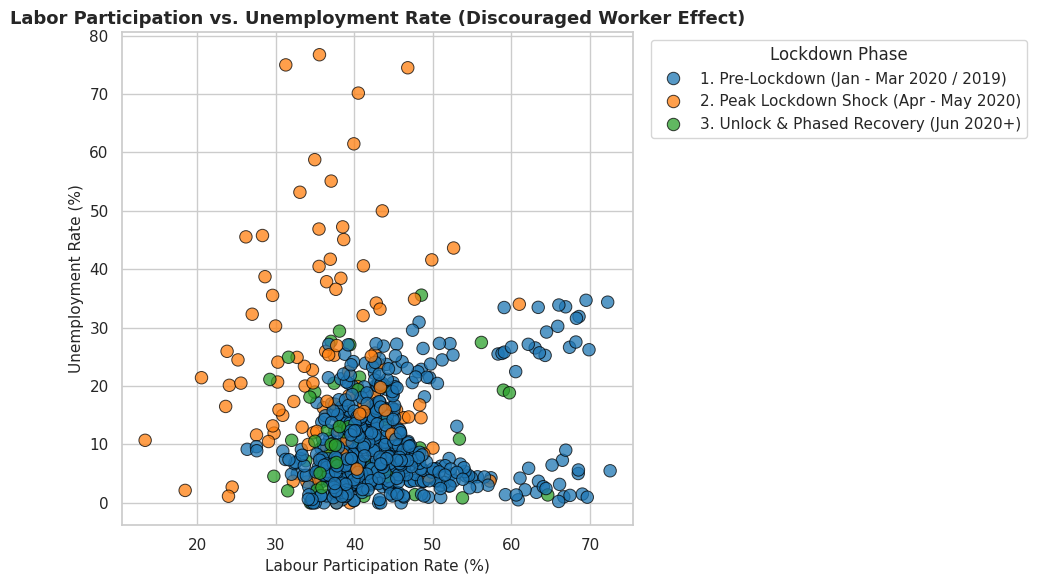

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Labour_Participation_Rate",
    y="Unemployment_Rate",
    hue="Lockdown_Phase",
    palette="tab10",
    alpha=0.75,
    s=80,
    edgecolor="black",
)

plt.title(
    "Labor Participation vs. Unemployment Rate (Discouraged Worker Effect)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Labour Participation Rate (%)", fontsize=11)
plt.ylabel("Unemployment Rate (%)", fontsize=11)
plt.legend(title="Lockdown Phase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()